# EE 344 — Final Project: Cardiovascular Risk Prediction (Regression + Classification)

In this notebook, we build an end-to-end ML pipeline to predict cardiovascular (heart attack) risk:

- A continuous **risk score** (0–100) *(regression)*
- A **risk category** (Low / Medium / High) *(3-class classification)*

We follow the project proposal:
- Use an **80/20** train/test split (classification split is **stratified**).
- Use **5-fold cross-validation** on the training set for model selection.
- Implement preprocessing with **scikit-learn Pipelines** to avoid data leakage.
- Report clear baselines and compare multiple model families.


## Setup
Run the next cell to import libraries and define helper functions.

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_auc_score
)

# Reproducibility
RANDOM_STATE = 42

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_regression(model, X_train, X_test, y_train, y_test):
    # Fit on train, evaluate on test.
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": rmse(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

def evaluate_classification(model, X_train, X_test, y_train, y_test):
    # Fit on train, evaluate on test.
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    out = {
        "Accuracy": accuracy_score(y_test, pred),
        "MacroF1": f1_score(y_test, pred, average="macro"),
    }
    # Optional: OVR ROC-AUC (requires probabilities or decision scores)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        out["ROC-AUC (OVR)"] = roc_auc_score(y_test, proba, multi_class="ovr")
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        out["ROC-AUC (OVR)"] = roc_auc_score(y_test, scores, multi_class="ovr")
    return out

class IQRClipper(BaseEstimator, TransformerMixin):
    # IQR-based clipping for numeric features.
    # Clips each numeric column to [Q1 - 1.5*IQR, Q3 + 1.5*IQR] computed on the training data only.
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * self.iqr_
        self.upper_ = self.q3_ + self.factor * self.iqr_
        return self

    def transform(self, X):
        X = np.asarray(X).astype(float)
        return np.clip(X, self.lower_, self.upper_)

def summarize_cv(cv_results, metrics):
    # Convert cross_validate output to a compact DataFrame: mean and std for each metric.
    rows = []
    for m in metrics:
        key = f"test_{m}"
        vals = cv_results[key]
        rows.append({
            "Metric": m,
            "Mean": np.mean(vals),
            "Std": np.std(vals),
        })
    return pd.DataFrame(rows)


## Load Dataset and Basic Statistics

- Load the dataset CSV.
- Print shape, columns, missing values.
- Show basic descriptive statistics.
- Show label distribution for the classification target.

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


Shape: (5500, 17)

Columns:
['Patient_ID', 'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'family_history_heart_disease', 'diet_quality_score', 'alcohol_units_per_week', 'heart_disease_risk_score', 'risk_category']

Missing values per column:


,Missing
Patient_ID,0
stress_level,0
heart_disease_risk_score,0
alcohol_units_per_week,0
diet_quality_score,0
family_history_heart_disease,0
sleep_hours,0
physical_activity_hours_per_week,0
daily_steps,0
age,0



Numeric summary stats:


,count,mean,std,min,25%,50%,75%,max
Patient_ID,5500.0,2750.500000,1587.857571,1.0,1375.75,2750.5,4125.25,5500.0
age,5500.0,53.872000,21.196017,18.0,36.00,54.0,72.00,90.0
bmi,5500.0,28.170818,4.189877,15.0,25.20,28.4,31.10,40.9
systolic_bp,5500.0,147.248182,13.222701,108.0,138.00,147.0,156.00,192.0
diastolic_bp,5500.0,95.756727,9.451559,64.0,89.00,96.0,102.00,120.0
cholesterol_mg_dl,5500.0,239.684182,28.570177,147.0,220.00,240.0,260.00,331.0
resting_heart_rate,5500.0,74.075091,6.392166,48.0,70.00,74.0,79.00,92.0
daily_steps,5500.0,5902.929455,3041.084590,500.0,3428.00,5460.0,7772.00,16793.0
stress_level,5500.0,4.907091,2.298173,1.0,3.00,5.0,7.00,10.0
physical_activity_hours_per_week,5500.0,3.299364,2.672457,0.0,1.20,2.6,4.90,12.9



Risk category distribution:


,Count
risk_category,
Medium,2244
Low,1838
High,1418


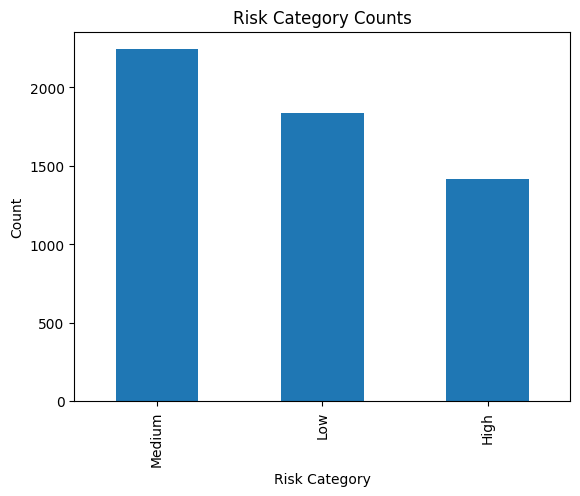

In [ ]:

DATA_PATH = "cardiovascular_risk_dataset.csv"  # put the CSV in the same folder as this notebook

df = pd.read_csv(DATA_PATH)
display(df.head())

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing"))

print("\nNumeric summary stats:")
display(df.describe(include=[np.number]).T)

print("\nRisk category distribution:")
display(df["risk_category"].value_counts(dropna=False).to_frame("Count"))

df["risk_category"].value_counts().plot(kind="bar")
plt.title("Risk Category Counts")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()


## Define Features and Targets

We use the same input features for both tasks.

Targets:
- **Regression**: `heart_disease_risk_score` (0–100)
- **Classification**: `risk_category` (Low / Medium / High)

In [ ]:

target_reg = "heart_disease_risk_score"
target_clf = "risk_category"

X = df.drop(columns=[target_reg, target_clf, "Patient_ID"])
y_reg = df[target_reg]
y_clf = df[target_clf]

print("X shape:", X.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


X shape: (5500, 15)
y_reg shape: (5500,)
y_clf shape: (5500,)

Categorical columns: ['smoking_status', 'family_history_heart_disease']
Numeric columns: ['Patient_ID', 'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score', 'alcohol_units_per_week']


## Train/Test Split (80/20)

We do **one split** that is **stratified** by the classification labels, and we reuse the same split for regression.

The test set stays untouched until the final evaluation.

In [4]:

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain risk category distribution:")
display(y_clf_train.value_counts().to_frame("Count"))

print("\nTest risk category distribution:")
display(y_clf_test.value_counts().to_frame("Count"))


Train size: 4400
Test size: 1100

Train risk category distribution:


,Count
risk_category,
Medium,1795
Low,1471
High,1134



Test risk category distribution:


,Count
risk_category,
Medium,449
Low,367
High,284


## Preprocessing Pipelines

We implement all preprocessing inside scikit-learn **Pipelines**.

Planned choices from the proposal:
- Missing values: numeric → **median**, categorical → **most frequent**
- Categorical encoding: **One-Hot**
- Scaling: **StandardScaler** or **RobustScaler** (comparison)
- Outlier handling: **IQR clipping** (comparison)

In [5]:

numeric_preprocess_standard = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

numeric_preprocess_robust = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", RobustScaler()),
])

numeric_preprocess_iqr_clip_then_standard = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("clip", IQRClipper(factor=1.5)),
    ("scale", StandardScaler()),
])

categorical_preprocess = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

def make_preprocessor(numeric_pipeline):
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_preprocess, categorical_cols),
        ],
        remainder="drop"
    )

preprocessor_standard = make_preprocessor(numeric_preprocess_standard)
preprocessor_robust = make_preprocessor(numeric_preprocess_robust)
preprocessor_iqr = make_preprocessor(numeric_preprocess_iqr_clip_then_standard)

preprocessor_standard


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['Patient_ID', 'age', 'bmi', 'systolic_bp',
                                  'diastolic_bp', 'cholesterol_mg_dl',
                                  'resting_heart_rate', 'daily_steps',
                                  'stress_level',
                                  'physical_activity_hours_per_week',
                                  'sleep_hours', 'diet_quality_score',
                                  'alcohol_units_per_week']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['smoking_status',
                                  'family_history_heart_disease'])])

## Baselines

We start with simple, interpretable baselines:
- **Regression baseline**: predict the mean training risk score.
- **Classification baseline**: predict the majority class.

In [6]:

reg_baseline = Pipeline(steps=[
    ("preprocess", preprocessor_standard),
    ("model", DummyRegressor(strategy="mean"))
])

clf_baseline = Pipeline(steps=[
    ("preprocess", preprocessor_standard),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

print("Regression baseline (test):", evaluate_regression(reg_baseline, X_train, X_test, y_reg_train, y_reg_test))
print("Classification baseline (test):", evaluate_classification(clf_baseline, X_train, X_test, y_clf_train, y_clf_test))


Regression baseline (test): {'MAE': 20.260613719008266, 'RMSE': np.float64(24.254942890808127), 'R2': -0.0002408348766658186}
Classification baseline (test): {'Accuracy': 0.4081818181818182, 'MacroF1': 0.19324295244243597, 'ROC-AUC (OVR)': np.float64(0.5)}


## Regression Models (5-Fold CV)

We compare multiple model families:
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor (with tuning)

We report mean and standard deviation across folds for RMSE, MAE, and R².

In [7]:

reg_scorers = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_models = {
    "LinearRegression (StandardScaler)": Pipeline(steps=[
        ("preprocess", preprocessor_standard),
        ("model", LinearRegression())
    ]),
    "Ridge (StandardScaler)": Pipeline(steps=[
        ("preprocess", preprocessor_standard),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "RandomForestRegressor (RobustScaler)": Pipeline(steps=[
        ("preprocess", preprocessor_robust),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

reg_cv_summaries = []
for name, model in reg_models.items():
    cv_out = cross_validate(model, X_train, y_reg_train, cv=kf, scoring=reg_scorers, n_jobs=-1)
    summary = summarize_cv(cv_out, metrics=list(reg_scorers.keys()))
    summary["Model"] = name
    reg_cv_summaries.append(summary)

reg_cv_df = pd.concat(reg_cv_summaries, ignore_index=True)

# Convert negative MAE/RMSE to positive for display
reg_cv_df["Mean"] = reg_cv_df.apply(lambda r: -r["Mean"] if r["Metric"] in ["rmse","mae"] else r["Mean"], axis=1)

display(reg_cv_df.pivot(index="Model", columns="Metric", values="Mean").round(4))


Metric,mae,r2,rmse
Model,,,
LinearRegression (StandardScaler),3.1813,0.9681,4.3375
RandomForestRegressor (RobustScaler),3.6293,0.9624,4.7085
Ridge (StandardScaler),3.1816,0.9681,4.3375


### Gradient Boosting Regressor (Hyperparameter Tuning)

We tune Gradient Boosting on the training set using 5-fold CV (primary metric: RMSE).

In [8]:

gbr = Pipeline(steps=[
    ("preprocess", preprocessor_standard),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_grid_gbr = {
    "model__n_estimators": [100, 200, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_leaf": [1, 5, 10],
}

gbr_search = GridSearchCV(
    gbr,
    param_grid=param_grid_gbr,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

gbr_search.fit(X_train, y_reg_train)

print("Best RMSE (CV):", -gbr_search.best_score_)
print("Best params:", gbr_search.best_params_)

best_gbr = gbr_search.best_estimator_


Best RMSE (CV): 3.450129438900896
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 10, 'model__n_estimators': 500}


## Classification Models (5-Fold Stratified CV)

We compare:
- Logistic Regression (multinomial)
- Random Forest Classifier
- Gradient Boosting Classifier (with tuning)

Primary metric: **Macro-F1**.

In [9]:

clf_scorers = {
    "macro_f1": "f1_macro",
    "accuracy": "accuracy",
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

clf_models = {
    "LogisticRegression (StandardScaler)": Pipeline(steps=[
        ("preprocess", preprocessor_standard),
        ("model", LogisticRegression(
            max_iter=2000,
            multi_class="multinomial",
            solver="lbfgs",
            random_state=RANDOM_STATE
        ))
    ]),
    "RandomForestClassifier (RobustScaler)": Pipeline(steps=[
        ("preprocess", preprocessor_robust),
        ("model", RandomForestClassifier(
            n_estimators=400,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

clf_cv_summaries = []
for name, model in clf_models.items():
    cv_out = cross_validate(model, X_train, y_clf_train, cv=skf, scoring=clf_scorers, n_jobs=-1)
    summary = summarize_cv(cv_out, metrics=list(clf_scorers.keys()))
    summary["Model"] = name
    clf_cv_summaries.append(summary)

clf_cv_df = pd.concat(clf_cv_summaries, ignore_index=True)
display(clf_cv_df.pivot(index="Model", columns="Metric", values="Mean").round(4))


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

Metric,accuracy,macro_f1
Model,,
LogisticRegression (StandardScaler),0.9375,0.9386
RandomForestClassifier (RobustScaler),0.8991,0.9011


### Gradient Boosting Classifier (Hyperparameter Tuning)

We tune Gradient Boosting on the training set using 5-fold stratified CV (primary metric: Macro-F1).

In [10]:

gbc = Pipeline(steps=[
    ("preprocess", preprocessor_standard),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gbc = {
    "model__n_estimators": [100, 200, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_leaf": [1, 5, 10],
}

gbc_search = GridSearchCV(
    gbc,
    param_grid=param_grid_gbc,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1
)

gbc_search.fit(X_train, y_clf_train)

print("Best Macro-F1 (CV):", gbc_search.best_score_)
print("Best params:", gbc_search.best_params_)

best_gbc = gbc_search.best_estimator_


Best Macro-F1 (CV): 0.9218132191198635
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


## Final Evaluation on the Held-Out Test Set

We evaluate the tuned Gradient Boosting models on the untouched test set.
This is the only time we report test performance.

=== Regression (Best GBR) ===
{'MAE': 2.7831949722957483, 'RMSE': np.float64(3.4805711107904784), 'R2': 0.9794029468256414}

=== Classification (Best GBC) ===
{'Accuracy': 0.9190909090909091, 'MacroF1': 0.9221858507936046, 'ROC-AUC (OVR)': np.float64(0.9891753641360527)}

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.92      0.94       284
         Low       0.93      0.92      0.92       367
      Medium       0.88      0.92      0.90       449

    accuracy                           0.92      1100
   macro avg       0.93      0.92      0.92      1100
weighted avg       0.92      0.92      0.92      1100



,High,Low,Medium
High,260,0,24
Low,0,337,30
Medium,9,26,414


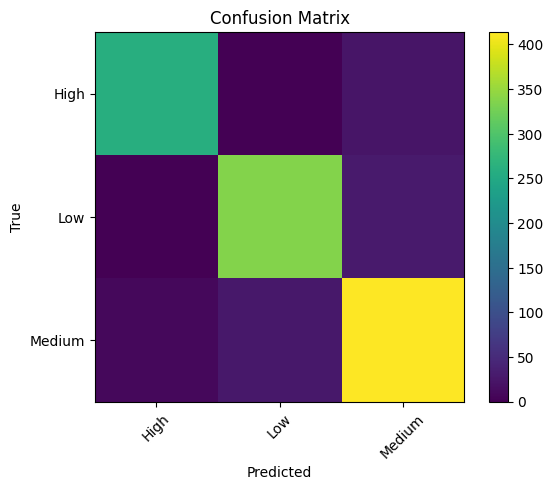

In [11]:

print("=== Regression (Best GBR) ===")
reg_test_metrics = evaluate_regression(best_gbr, X_train, X_test, y_reg_train, y_reg_test)
print(reg_test_metrics)

print("\n=== Classification (Best GBC) ===")
clf_test_metrics = evaluate_classification(best_gbc, X_train, X_test, y_clf_train, y_clf_test)
print(clf_test_metrics)

best_gbc.fit(X_train, y_clf_train)
y_pred = best_gbc.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred))

labels = sorted(y_clf_test.unique())
cm = confusion_matrix(y_clf_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xticks(range(cm.shape[1]), labels, rotation=45)
plt.yticks(range(cm.shape[0]), labels)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Feature Importance (Interpretability)

We extract feature importances from the tuned tree-based models.

Note: one-hot encoding expands categorical features, so we first recover the expanded feature names.

,Feature,Importance
3,systolic_bp,0.562161
5,cholesterol_mg_dl,0.289405
1,age,0.031086
9,physical_activity_hours_per_week,0.028437
13,smoking_status_Current,0.026564
15,smoking_status_Never,0.016332
2,bmi,0.014509
16,family_history_heart_disease_No,0.014147
17,family_history_heart_disease_Yes,0.013629
8,stress_level,0.001774


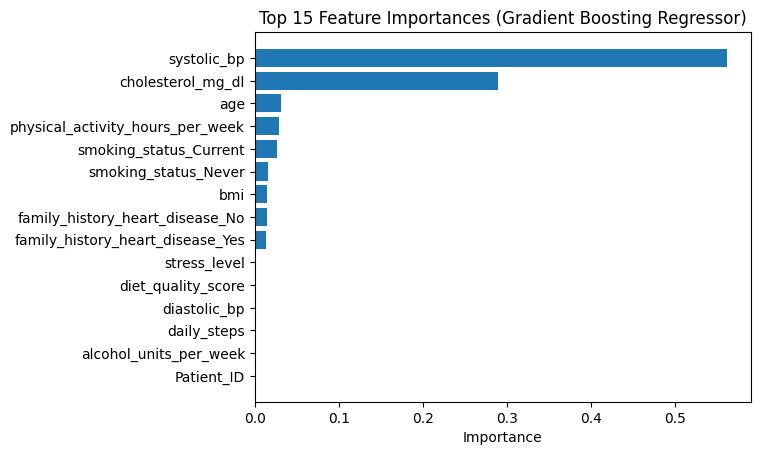

,Feature,Importance
3,systolic_bp,0.635502
5,cholesterol_mg_dl,0.181993
1,age,0.040591
2,bmi,0.025204
13,smoking_status_Current,0.025009
15,smoking_status_Never,0.021619
17,family_history_heart_disease_Yes,0.018366
9,physical_activity_hours_per_week,0.016046
16,family_history_heart_disease_No,0.013218
7,daily_steps,0.004943


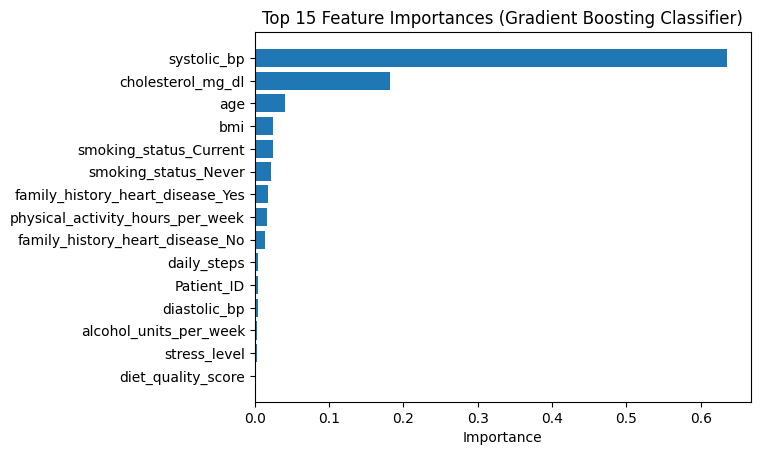

In [12]:

def get_feature_names(preprocessor):
    out = []
    for name, trans, cols in preprocessor.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                fn = trans.get_feature_names_out(cols)
            except TypeError:
                fn = trans.get_feature_names_out()
            out.extend(fn)
        else:
            if hasattr(trans, "named_steps"):
                last = list(trans.named_steps.values())[-1]
                if hasattr(last, "get_feature_names_out"):
                    fn = last.get_feature_names_out(cols)
                    out.extend(fn)
                else:
                    out.extend(cols)
            else:
                out.extend(cols)
    return np.array(out, dtype=object)

# Regression feature importances
best_gbr.fit(X_train, y_reg_train)
gbr_pre = best_gbr.named_steps["preprocess"]
gbr_model = best_gbr.named_steps["model"]
gbr_names = get_feature_names(gbr_pre)

gbr_imp = pd.DataFrame({
    "Feature": gbr_names,
    "Importance": gbr_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(gbr_imp.head(15))

plt.figure()
plt.barh(gbr_imp.head(15)["Feature"][::-1], gbr_imp.head(15)["Importance"][::-1])
plt.title("Top 15 Feature Importances (Gradient Boosting Regressor)")
plt.xlabel("Importance")
plt.show()

# Classification feature importances
best_gbc.fit(X_train, y_clf_train)
gbc_pre = best_gbc.named_steps["preprocess"]
gbc_model = best_gbc.named_steps["model"]
gbc_names = get_feature_names(gbc_pre)

gbc_imp = pd.DataFrame({
    "Feature": gbc_names,
    "Importance": gbc_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(gbc_imp.head(15))

plt.figure()
plt.barh(gbc_imp.head(15)["Feature"][::-1], gbc_imp.head(15)["Importance"][::-1])
plt.title("Top 15 Feature Importances (Gradient Boosting Classifier)")
plt.xlabel("Importance")
plt.show()


## Discussion and Conclusion

- Compare results against baselines.
- Identify which features appear most important.
- Comment on whether performance is balanced across classes (Macro-F1 vs Accuracy).
- Note limitations: synthetic data, snapshot-only records, and any class imbalance.

**Key takeaway:** A leakage-safe pipeline plus strong tabular baselines (especially gradient boosting) can predict both a continuous risk score and a risk category using common health and lifestyle indicators.